# Data cleansing and extraction:

The dataset we will be using during this project can be found both on [Kaggle](https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset?resource=download) and University of California, Irvine's ML [Repository](https://archive.ics.uci.edu/dataset/31/covertype) (where, in addition to the data, you can find a more extended explanaition on the variable meaning that the Kaggle page lacks).

Let's begin by extracting the data and loading it to a Pandas dataframe:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/covtype.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

## General overview of the dataset:

The dataset is pretty heavy (almost 0.25 GB). On a first sight, we can see that:
- **Number of entries and columns:** There are more than half a million entries and more than 50 columns!
- **Features:** Although all the features are saved as numeric data types, not all of them represent numeric variables. Many of them are categorical variables converted to numeric types.
- **cover_type** is the target variable we want to predict. It's a categorical variable converted to a numeric data type. Our objective, therefore, is to build classification models that are able to predict the forest cover type.

With such a big set of information, we can apply many different classical Machine Learning (and maybe some basic neural network) models to try to predict the possible cover_type of a pixel.

### Features:

Our feature variables are classified in the following way:
- 10 countinuous variables:
    * Elevation (m)
    * Aspect (azimuth, degrees from North)
    * Slope (degrees)
    * Horizontal_Distance_To_Hydrology (m)
    * Vertical_Distance_To_Hydrology (m)
    * Horizontal_Distance_To_Roadways (m)
    * Hillshade_9am (index, from 0 to 255)
    * Hillshade_Noon (index, from 0 to 255)
    * Hillshade_3pm (index, from 0 to 255)
    * Horizontal_Distance_To_Fire_Points (m)
- Categorical variables:
    * Willderness_Area: 4 wilderness areas ara included in the dataset (*Rawah, Neota, Comanche Peak* and *Cache la Poudre*). Using **one hot encoding**, a column was created to indicate belonging to one of the four wilderness areas. The columns that belong to each wilderness area are:
        - Rawah: area 1.
        - Neota: area 2.
        - Comanche Peak: area 3.
        - Coche la Poudre: area 4.
    * Soil_type: 40 different soil types were included. The soil type is **one hot encoded**.

### Target variable:

Let's check how many categories our target variable `cover_type` has:

In [3]:
df["Cover_Type"].value_counts().sort_values()

Cover_Type
4      2747
5      9493
6     17367
7     20510
3     35754
1    211840
2    283301
Name: count, dtype: int64

The category/tree cover behind each value is the following:
- Cover type 1: spruce/fir (*Picea/Abeto in Spanish*).
- Cover type 2: lodgepole pine
- Cover type 3: Ponderosa pine
- Cover type 4: cottonwood/willow (*álamo de Norteamérica/sauce*)
- Cover type 5: aspen (*álamo temblón*)
- Cover type 6: Douglas-fir
- Cover type 7: krummholz

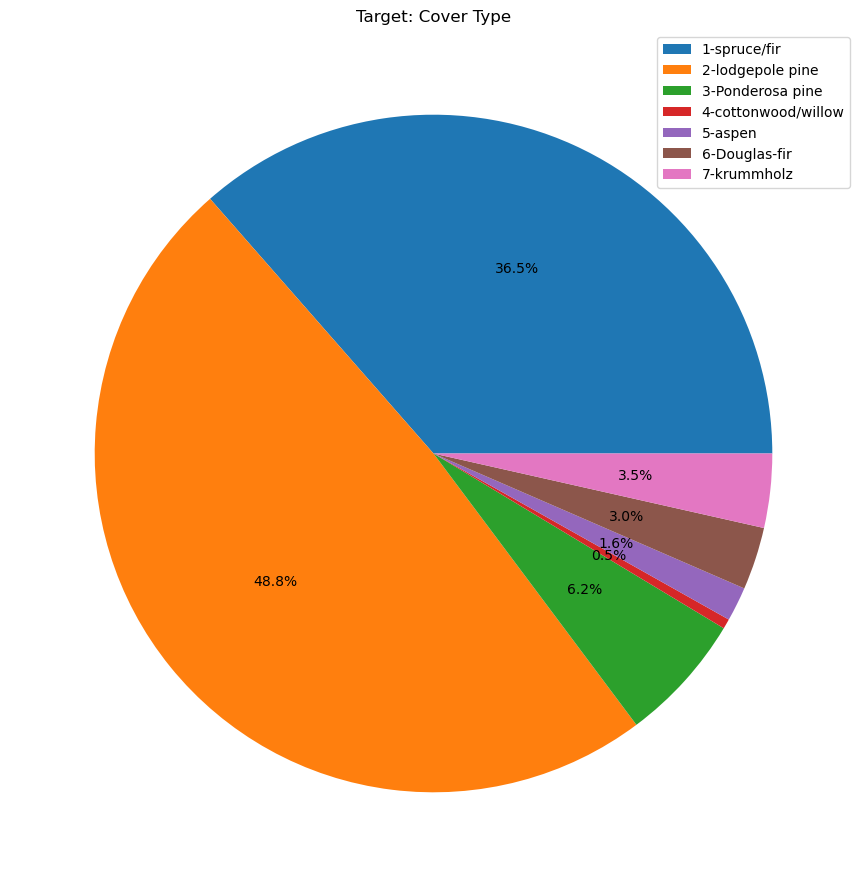

In [3]:
labels = ["spruce/fir",
         "lodgepole pine",
         "Ponderosa pine",
          "cottonwood/willow",
          "aspen",
          "Douglas-fir",
          "krummholz"
]

labels = [str(i+1) + '-' + labels[i] for i in range(len(labels))]

plt.figure(figsize=(11,11))
plt.pie( df["Cover_Type"].value_counts().sort_index(), autopct='%1.1f%%')
plt.title("Target: Cover Type")
#plt.legend(labels = df["Cover_Type"].value_counts().index, loc = "upper right")
plt.legend(labels = labels, loc = "upper right");

We see that the cover type distribution is not uniform. There are far more type 2 and 1 cover types than type 4. Cover types 3, 4, 5, 6 and 7 are under represented. 

This is a challenge we will need to face later, while training our models, as it is recommended that the target variable should be equally distributed in the training dataset.

### Null values:

Our dataset is already cleaned and lacks Null values:

In [6]:
df.count()

Elevation                             581012
Aspect                                581012
Slope                                 581012
Horizontal_Distance_To_Hydrology      581012
Vertical_Distance_To_Hydrology        581012
Horizontal_Distance_To_Roadways       581012
Hillshade_9am                         581012
Hillshade_Noon                        581012
Hillshade_3pm                         581012
Horizontal_Distance_To_Fire_Points    581012
Wilderness_Area1                      581012
Wilderness_Area2                      581012
Wilderness_Area3                      581012
Wilderness_Area4                      581012
Soil_Type1                            581012
Soil_Type2                            581012
Soil_Type3                            581012
Soil_Type4                            581012
Soil_Type5                            581012
Soil_Type6                            581012
Soil_Type7                            581012
Soil_Type8                            581012
Soil_Type9

In [7]:
df.count().value_counts()

581012    55
Name: count, dtype: int64

All columns have the same amount of non-null values.

## Plots:

Let's check what the relations that the different variables have with each other.

### Predictor variables:

One of the main variables that can heavily influence the target is the **Wilderness Area**, which is one-hot encoded into 4 columns. Each wilderness area encompasses different ranges of altitude, other numerical variables and soil types. It is useful to see how the wilderness area influences the rest of the variables.

Before anything else, we need to invert the one hot encoding of the wilderness area and create a column that includes 4 values, one for each wilderness area.

In [32]:
df["Wilderness_Area"] = df["Wilderness_Area1"]
for i in range(2, 5):
    df.loc[df[f"Wilderness_Area{i}"] == 1, "Wilderness_Area"] = i

df["Wilderness_Area"].value_counts()

Wilderness_Area
1    260796
3    253364
4     36968
2     29884
Name: count, dtype: int64

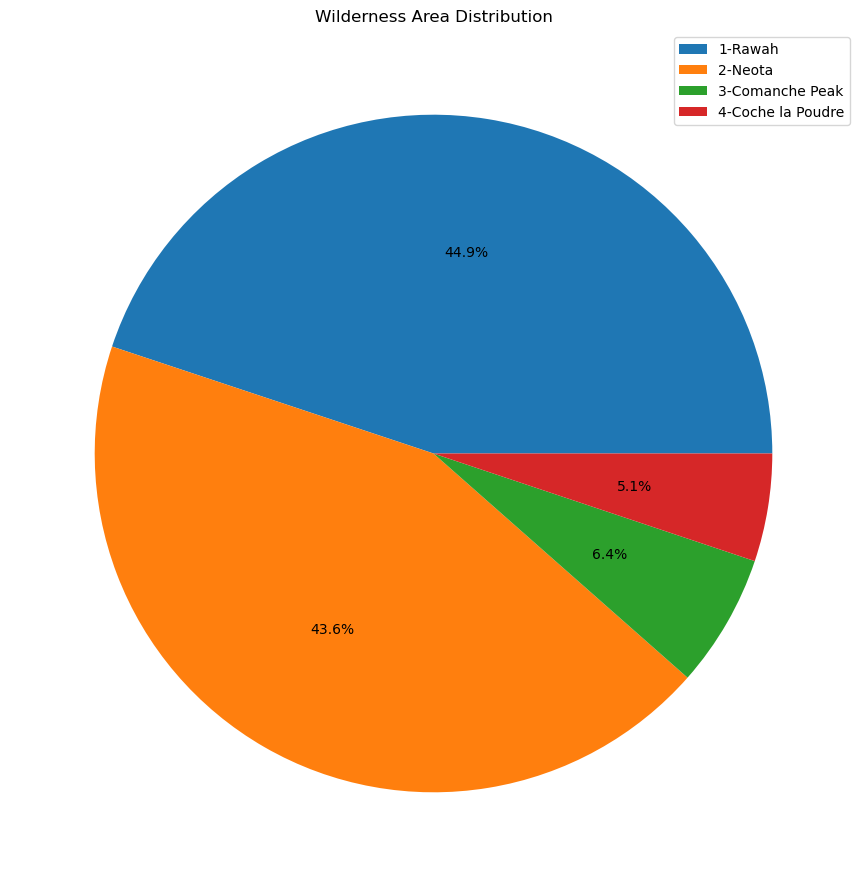

In [44]:
names = ["Rawah", "Neota", "Comanche Peak", "Coche la Poudre"]

labels = [f"{i+1}-{names[i]}" for i in range(len(names))]

plt.figure(figsize=(11,11))
plt.pie( df["Wilderness_Area"].value_counts(), autopct='%1.1f%%')
plt.title("Wilderness Area Distribution")
plt.legend(labels = labels, loc = "upper right");

In [56]:
df[["Elevation", "Wilderness_Area"]].groupby("Wilderness_Area").mean()

,Elevation
Wilderness_Area,
1,3000.267286
2,3245.727814
3,2980.554471
4,2294.106038


In [58]:
df[["Elevation", "Wilderness_Area"]].groupby("Wilderness_Area").describe()

Elevation                                                   \
                    count         mean         std     min     25%     50%   
Wilderness_Area                                                              
1                260796.0  3000.267286  200.271001  2473.0  2870.0  3002.0   
2                 29884.0  3245.727814  112.384540  2945.0  3168.0  3240.0   
3                253364.0  2980.554471  239.272648  2270.0  2820.0  2997.0   
4                 36968.0  2294.106038  150.903974  1859.0  2188.0  2313.0   

                                 
                    75%     max  
Wilderness_Area                  
1                3151.0  3686.0  
2                3319.0  3647.0  
3                3160.0  3858.0  
4                2409.0  2654.0

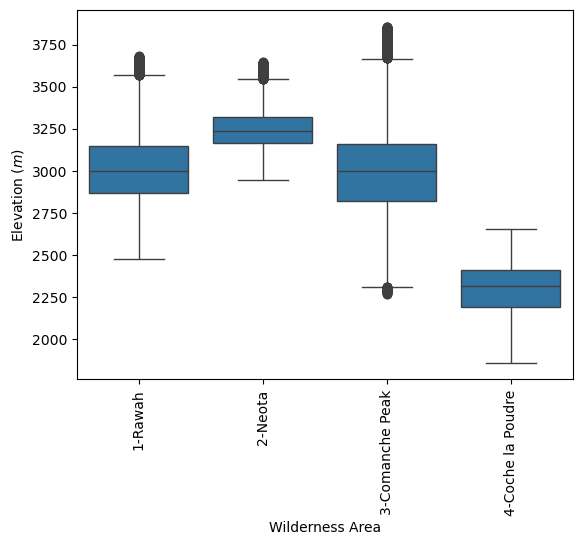

In [57]:
sns.boxplot(df, x = "Wilderness_Area", y="Elevation")
plt.xlabel("Wilderness Area")
plt.ylabel(r"Elevation ($m$)")
plt.xticks([*range(4)], labels, rotation=90);

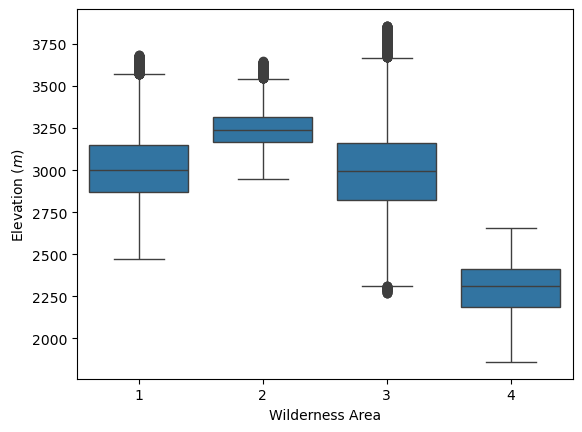

In [53]:
sns.boxplot(df, x = "Wilderness_Area", y="Elevation")
plt.xlabel("Wilderness Area")
plt.ylabel(r"Elevation ($m$)")
plt.xticks([*range(4)], [*range(1,5)]);

What can be seen from the previous plots?
- The first three wilderness areas have, Rawah, Neota and Comanche Peak, have high average elevation, around 3000 m.
- Coche la Poudre has the lowest mean elevation, slightly below 2300 m.

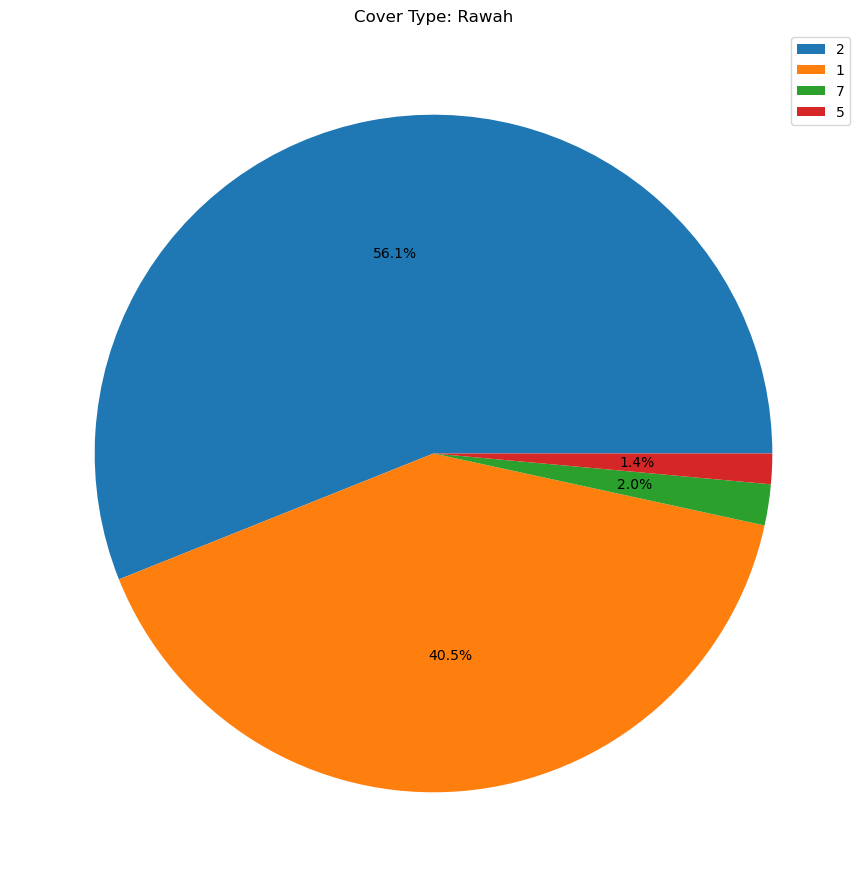

In [77]:
ct1 = df.loc[df["Wilderness_Area"] == 1, "Cover_Type"].value_counts()
labels = [f"{i+1}-{names[i]}" for i in range(len(names))]

plt.figure(figsize=(11,11))
plt.pie(ct1, autopct="%1.1f%%")
#plt.pie( df["Wilderness_Area"].value_counts(), autopct='%1.1f%%')
plt.title("Cover Type: Rawah")
plt.legend(labels = ct1.index, loc = "upper right");

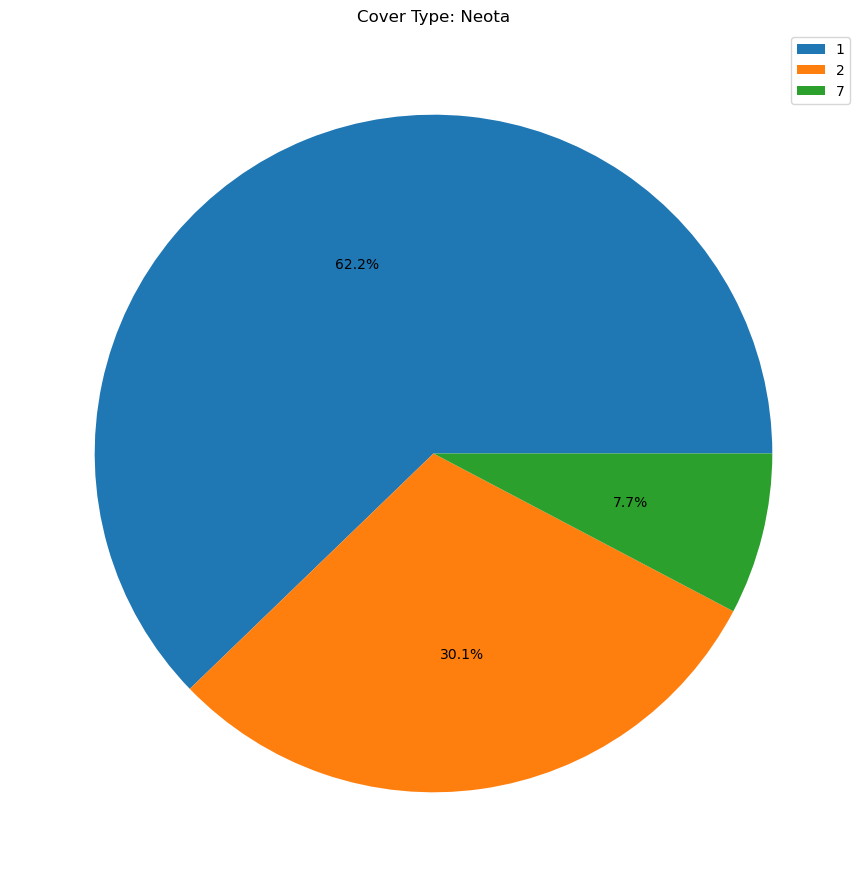

In [79]:
ct1 = df.loc[df["Wilderness_Area"] == 2, "Cover_Type"].value_counts()
labels = [f"{i+1}-{names[i]}" for i in range(len(names))]

plt.figure(figsize=(11,11))
plt.pie(ct1, autopct="%1.1f%%")
#plt.pie( df["Wilderness_Area"].value_counts(), autopct='%1.1f%%')
plt.title("Cover Type: Neota")
plt.legend(labels = ct1.index, loc = "upper right");

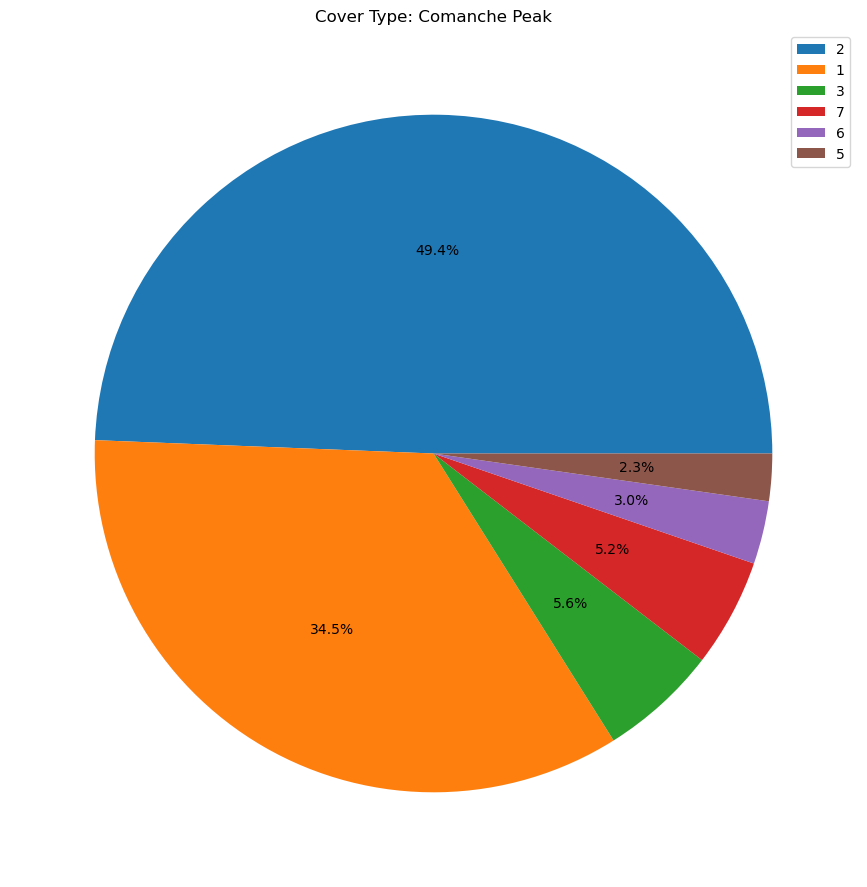

In [80]:
ct1 = df.loc[df["Wilderness_Area"] == 3, "Cover_Type"].value_counts()
labels = [f"{i+1}-{names[i]}" for i in range(len(names))]

plt.figure(figsize=(11,11))
plt.pie(ct1, autopct="%1.1f%%")
#plt.pie( df["Wilderness_Area"].value_counts(), autopct='%1.1f%%')
plt.title("Cover Type: Comanche Peak")
plt.legend(labels = ct1.index, loc = "upper right");

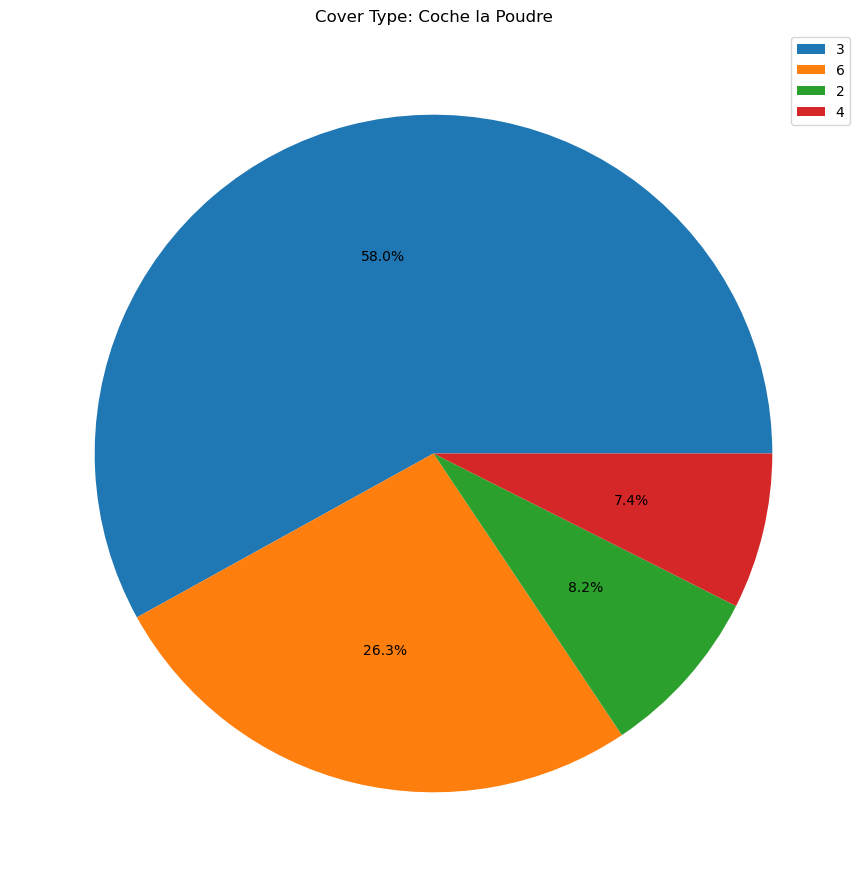

In [81]:
ct1 = df.loc[df["Wilderness_Area"] == 4, "Cover_Type"].value_counts()
labels = [f"{i+1}-{names[i]}" for i in range(len(names))]

plt.figure(figsize=(11,11))
plt.pie(ct1, autopct="%1.1f%%")
#plt.pie( df["Wilderness_Area"].value_counts(), autopct='%1.1f%%')
plt.title("Cover Type: Coche la Poudre")
plt.legend(labels = ct1.index, loc = "upper right");

## Pruebas

In [ ]:
sns.histplot(df["Hillshade_9am"])

In [ ]:
df["Hillshade_9am"].head()

In [ ]:
df["Wilderness_Area"] = pd.Series(df["Wilderness_Area1"] == 1).astype(int)

In [ ]:
df.loc[df["Wilderness_Area2"] == 1, "Wilderness_Area"] = 2 

In [ ]:
df["Wilderness_Area"].value_counts()

## Open questions: to be answered in the future

1. Are different soil types compatible? I mean: is it possible for a pixel to have more than one soil type, and thus have more than one True value in the soil columns?
2. Are all soil types equally represented? Is there a soil type with mostly `False` values? If the latter is true, we could drop that column.
3. Can we group the different soil types into a smaller number of columns? Maybe different soil types show themselves in groups. In that case, we could just create a new column per group and drop the individual columns.
4. From the ML point of view: which are the most influential columns? How much can we simplify the dataset by dropping columns?
5. Is it possible to reduce the amount of columns by combining them in a single column? Not by creating columns that represent soil type groups, but by merging all of them (or as many of them as possible) in a single column, where each soil type would be represented by an index value.

## Future steps:
(provisional, this cell will be moved to a different notebook or file in the future)

- Is this compatible with other forests (forests with other tree species)? Is it compatible with other forest types?
- Can it be combined with satellite data?
- Is it possible to create a pipeline where satellite data would be preprocessed with ML algorithms (CV?) to get scalar values that represent each soil type and then combine it to the model developed in this project to guess cover type? Would this provide any improvement from directly predicting the tree type with CV?

In [ ]:
df["Cover_Type"].sort_values().unique() # ADI: interesgarria. Zer izango da eraginkorragoa? Lehenik unique() egitea ala sort_values() egitea?

In [14]:
df.loc[:, "Soil_Type1":"Soil_Type40"].sum(axis=1).value_counts()

1    581012
Name: count, dtype: int64